In [1]:
# 1. Fetch Source Bids
import os
import sys
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pytz

import dash
from dash import dcc, html, Input, Output, State, callback, dash_table
import dash_bootstrap_components as dbc
from dash.dash_table.Format import Format, Scheme, Sign, Symbol
from dash.exceptions import PreventUpdate
import plotly.graph_objects as go

sys.path.append("/var/www/python/Prod/nighthawk/")

from nighthawk.util import connections, sql_functions
from nighthawk.data.product.ve import DailyBidsManager
from nighthawk.data.network.node import Node
from nighthawk.viz.giraffe.common_functions import (get_fig, FCC_card, create_title_row, layout_style,
                                                    
    
    FCC_datePickerSingle, FCC_input, FCC_dropdown, FCC_button,
    get_callbackFunction_page_usage_counter
)

# Get DA price

In [3]:
#!/usr/bin/env python3
"""
SPP Day-Ahead LMP download and processing pipeline (pure Python).

Replaces the PHP flow in SPP_download_DART_LMP.php when mode=da:
  1. Read DA LMP CSVs from SPP FTP in memory (pd.read_csv), process to dataframe.
  2. Merge with node list, upload to spp_lmp.settlement_location_da_hourly via sql_functions.
  3. Update node list (spp_core.spp_settlement_location_node_list) for new settlement locations.
  4. Optionally find (dt, hr) missing in last lookback_days and repopulate by re-downloading those dates.
  5. Update VE clear_price from DA and allocate cleared MW.
  6. Update LMP summary tables (daily, monthly, quarterly, annual for DA and RT last-30-days).

Calling:
  python3 spp_dataDownload_da_lmp.py [start_dt] [end_dt] [lookback_days]
  start_dt, end_dt: optional; date range to download (default: next calendar day).
  lookback_days: optional; days to check for missing (dt, hr) and repopulate (default 7; 0 = skip gap fill).
"""

from __future__ import print_function

import sys
import random
import ftplib
from datetime import datetime, timedelta
from io import BytesIO

import pandas as pd
import pytz

sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.util import sql_functions, dataframe_functions

sys.path.append("/var/www/python/Prod/COMMON/monitoring/notification_system/")
from send_msg_through_slack import send_msg_through_slack

sys.path.append("/var/www/python/Prod/SPP/DataDownload/LMP/")
from spp_update_lmp_summary import run_cron_job_summaries

# Config
FTP_HOST = 'pubftp-mte.itespp.org'
FTP_BASE = '/Markets/DA/LMP_By_SETTLEMENT_LOC'
# Per-day file path under FTP_BASE: YYYY/MM/By_Day/DA-LMP-SL-YYYYMMDD0100.csv
TZ = pytz.timezone('America/Chicago')

LMP_TABLE = 'spp_temp.settlement_location_da_hourly_mte'
NODE_LIST_TABLE = 'spp_core.spp_settlement_location_node_list'
MIN_ROWS_QC = 100  # skip file if too few valid rows
BAA_CSV_COL = 'BAA'  # optional column; present once SPP adds it to the data source
script_name = 'spp_dataDownload_da_lmp.py'
warning_string = ''


def _csv_to_dataframe(io_or_path, source=None):
    """Parse one DA LMP CSV (file-like or path) into a dataframe with dt, hr, settlement_location, da_value, marginalloss_value, congestional_value."""
    df = pd.read_csv(io_or_path)
    df.columns = df.columns.str.strip()
    df = df[df['Settlement Location'].notna() & df['Interval'].notna()].copy()
    df['Interval'] = pd.to_datetime(df['Interval'], errors='coerce')
    df = df[df['Interval'].dt.year > 2000].copy()
    if df.empty:
        return df
    # DA rule: Interval - 1 hour -> dt (date) and hr 1-24 (midnight -> previous day, hr 24)
    shifted = df['Interval'] - pd.Timedelta(hours=1)
    df['dt'] = shifted.dt.strftime('%Y-%m-%d')
    df['hr'] = shifted.dt.hour + 1
    df['settlement_location'] = df['Settlement Location'].astype(str).str.strip()
    df['da_value'] = pd.to_numeric(df['LMP'], errors='coerce').fillna(0).astype(float)
    df['marginalloss_value'] = pd.to_numeric(df['MLC'], errors='coerce').fillna(0).astype(float)
    df['congestional_value'] = pd.to_numeric(df['MCC'], errors='coerce').fillna(0).astype(float)
    cols = ['dt', 'hr', 'settlement_location', 'da_value', 'congestional_value', 'marginalloss_value']
    df['baa_zone'] = df[BAA_CSV_COL].astype(str).str.strip().map({'SPP': 'E', 'SWPW': 'W','':'W'}).fillna('SPP')
    cols.append('baa_zone')
    return df[cols]


def fetch_da_lmp_dataframe_from_ftp(start_dt, end_dt):
    """
    Fetch DA LMP CSV for each date in [start_dt, end_dt] from SPP FTP (one file per day:
    .../YYYY/MM/By_Day/DA-LMP-SL-YYYYMMDD0100.csv), read in memory, return one concatenated dataframe.
    """
    start_dt = pd.to_datetime(start_dt).date()
    end_dt = pd.to_datetime(end_dt).date()
    if start_dt > end_dt:
        return pd.DataFrame()

    ftp = ftplib.FTP(FTP_HOST)
    ftp.login('anonymous', 'download')
    frames = []
    for d in pd.date_range(start=start_dt, end=end_dt):
        dt = d.date()
        year, month, day = dt.year, dt.month, dt.day
        file_name = 'DA-LMP-SL-{:04d}{:02d}{:02d}0100.csv'.format(year, month, day)
        remote_dir = '{}/{}/{:02d}/By_Day'.format(FTP_BASE, year, month)
        try:
            ftp.cwd(remote_dir)
            bio = BytesIO()
            ftp.retrbinary('RETR ' + file_name, bio.write)
            bio.seek(0)
            one = _csv_to_dataframe(bio, source=file_name)
            if len(one) >= MIN_ROWS_QC:
                frames.append(one)
                print('Processed {} ({} rows)'.format(file_name, len(one)))
            else:
                print('Skipped {} (too few rows: {})'.format(file_name, len(one)))
        except ftplib.error_perm:
            print('FTP failed {} (By_Day dir)'.format(file_name))
        except Exception as e:
            print('Failed {}: {}'.format(file_name, e))
    ftp.quit()

    if not frames:
        print('No CSV data loaded.')
        return pd.DataFrame()
    out = pd.concat(frames, ignore_index=True)
    out = out.drop_duplicates(subset=['dt', 'hr', 'settlement_location'], keep='last')
    print('Total rows: {}'.format(len(out)))
    return out


def update_da_lmp_from_dataframe(df):
    """
    Merge df with node list (from DB), insert new settlement locations into node list,
    then upload LMP dataframe directly to spp_lmp.settlement_location_da_hourly. No temp table.

    If the source data contains a BAA column (parsed as baa_zone), this function also:
      - Updates baa_zone in NODE_LIST_TABLE for existing nodes where the value has changed.
      - Populates baa_zone when inserting new nodes.
    baa_zone is never written to the LMP tables (sl_rt_5_min / settlement_location_*_hourly).
    """
    if df.empty:
        print('No data to update.')
        return

    has_baa = 'baa_zone' in df.columns

    # Get node list from DB
    node_list = sql_functions.download_df_from_sql_db(
        "SELECT node_num, node_name FROM {}".format(NODE_LIST_TABLE)
    )
    df = df.merge(node_list, left_on='settlement_location', right_on='node_name', how='left')
    df = df.drop(columns=['node_name'], errors='ignore')
    # node_num may be NaN for new locations

    # Rows to upload to LMP table (must have node_num)
    lmp_upload = df.loc[df['node_num'].notna() & (df['node_num'] > 0)].copy()
    if lmp_upload.empty:
        print('No rows with node_num to upload.')
        return
    
    #Align columns to the exact order of LMP_TABLE; fill any unexpected missing columns with NaN.
    lmp_table_cols = sql_functions.download_df_from_sql_db(
        "SELECT * FROM {} LIMIT 1".format(LMP_TABLE)
    ).columns.tolist()
    lmp_upload = lmp_upload[lmp_table_cols]
    sql_functions.replace_into_sql_table(lmp_upload, LMP_TABLE)

    print('CSV to DB update done.')


def main():
    timezone = pytz.timezone('America/Chicago')
    now = datetime.now(timezone)
    next_day = (now + timedelta(days=1)).strftime('%Y-%m-%d')

    try:
        start_dt = pd.to_datetime(sys.argv[1]).strftime('%Y-%m-%d')
    except (IndexError, ValueError):
        start_dt = next_day
    try:
        end_dt = pd.to_datetime(sys.argv[2]).strftime('%Y-%m-%d')
    except (IndexError, ValueError):
        end_dt = start_dt

    lookback_days = 7
    if len(sys.argv) > 3:
        try:
            lookback_days = int(sys.argv[3])
        except ValueError:
            pass

    print('start_dt: {}, end_dt: {}, lookback_days (gap fill): {}'.format(start_dt, end_dt, lookback_days))
    if pd.to_datetime(start_dt) > pd.to_datetime(end_dt):
        print('Start date must be <= end date. Exiting.')
        sys.exit(1)

    print('\nGetting LMP data from FTP (in memory)...')
    df = fetch_da_lmp_dataframe_from_ftp('2026-04-06', '2026-04-06')
    print('done')
    print(df.head())

    if not df.empty:
        print('\nUpdating data in tables...')
        update_da_lmp_from_dataframe(df)
        print('done')


    # print('\nSummarizing daily/monthly/etc tables....')
    # run_cron_job_summaries()

if __name__ == '__main__':
    main()


start_dt: 2026-04-07, end_dt: 2026-04-07, lookback_days (gap fill): 7

Getting LMP data from FTP (in memory)...
Processed DA-LMP-SL-202604060100.csv (37872 rows)
Total rows: 37872
done
           dt  hr settlement_location  da_value  congestional_value  \
0  2026-04-06   1                 AEC  172.6067                 0.0   
1  2026-04-06   1           AECC_CSWS  174.7334                 0.0   
2  2026-04-06   1         AECC_ELKINS  173.1933                 0.0   
3  2026-04-06   1       AECC_FITZHUGH  175.4805                 0.0   
4  2026-04-06   1       AECC_FLTCREEK  171.1670                 0.0   

   marginalloss_value baa_zone  
0             -0.6522        E  
1              1.4745        E  
2             -0.0656        E  
3              2.2216        E  
4             -2.0919        E  

Updating data in tables...
CSV to DB update done.
done


# Get RT price

In [4]:
#!/usr/bin/env python3
"""
SPP Real-Time LMP live-interval download and processing pipeline (pure Python).

Replaces the PHP flow in SPP_download_DART_LMP.php when mode=rt:
  1. Fetch RTBM-LMP-SL-latestInterval.csv from SPP FTP in memory.
  2. Parse CSV: Interval - 5 min gives dt/hr (hr 1-24), forecast_time = raw Interval.
  3. Insert new settlement locations into spp_core.spp_settlement_location_node_list.
  4. REPLACE INTO spp_lmp.sl_rt_5_min (resolved node_nums only).
  5. REPLACE INTO spp_lmp.settlement_location_rt_hourly (avg of 5-min for dt/hr/node).
  6. DELETE from sl_rt_5_min rows older than 14 days.
  7. Find specific forecast_time values missing from spp_lmp.sl_rt_5_min in the last
     lookback_hours and re-download exactly those By_Interval files from the SPP FTP.
     e.g. a missing 2026-03-11 00:45:00 → fetches
     /Markets/RTBM/LMP_By_SETTLEMENT_LOC/2026/03/By_Interval/11/RTBM-LMP-SL-202603110045.csv

For backfilling whole historical dates from the By_Day consolidated files (published ~1 week
later), use spp_dataDownload_daily_rt_lmp.py instead.

Calling:
  python3 spp_dataDownload_rt_lmp.py [lookback_hours]
  lookback_hours : optional; hours to scan for missing intervals (default 4; 0 = skip gap fill).
"""

from __future__ import print_function

import sys
import ftplib
from datetime import datetime, timedelta
from io import BytesIO

import pandas as pd
import pytz

sys.path.append("/var/www/python/Prod/nighthawk/")
from nighthawk.util import sql_functions

sys.path.append("/var/www/python/Prod/COMMON/monitoring/notification_system/")
from send_msg_through_slack import send_msg_through_slack

# Config
FTP_HOST     = 'pubftp-mte.itespp.org'
FTP_RT_BASE  = '/Markets/RTBM/LMP_By_SETTLEMENT_LOC'
FTP_RT_LATEST = FTP_RT_BASE + '/RTBM-LMP-SL-latestInterval.csv'
TZ       = pytz.timezone('America/Chicago')

SL_RT_5MIN_TABLE = 'spp_temp.settlement_location_rt_5_min_mte'
RT_HOURLY_TABLE  = 'spp_temp.settlement_location_rt_hourly_mte'
NODE_LIST_TABLE  = 'spp_core.spp_settlement_location_node_list'

BAA_CSV_COL = 'BAA'  # optional column; present once SPP adds it to the data source
baamap = {'SPP':'E','SWPW':"W"}

script_name    = 'spp_dataDownload_rt_lmp.py'
warning_string = ''


def _csv_to_dataframe(io_or_path):
    """Parse one RT LMP interval CSV into a dataframe."""
    df = pd.read_csv(io_or_path)
    df.columns = df.columns.str.strip()
    df = df[df['Settlement Location'].notna() & df['Interval'].notna()].copy()
    df['Interval'] = pd.to_datetime(df['Interval'], errors='coerce')
    df = df[df['Interval'].dt.year > 2000].copy()
    if df.empty:
        return df

    df['forecast_time']      = df['Interval'].dt.strftime('%Y-%m-%d %H:%M:%S')
    shifted                  = df['Interval'] - pd.Timedelta(minutes=5)
    df['dt']                 = shifted.dt.strftime('%Y-%m-%d')
    df['hr']                 = shifted.dt.hour + 1
    df['settlement_location']= df['Settlement Location'].astype(str).str.strip()
    df['rt_value']           = pd.to_numeric(df['LMP'], errors='coerce').fillna(0).astype(float)
    df['marginalloss_value'] = pd.to_numeric(df['MLC'], errors='coerce').fillna(0).astype(float)
    df['congestional_value'] = pd.to_numeric(df['MCC'], errors='coerce').fillna(0).astype(float)
    if 'BAA' in df.columns:
        df['BAA'] = df['BAA'].map(baamap)
    else:
        df['BAA'] = None

    return df[['forecast_time', 'dt', 'hr', 'settlement_location',
               'rt_value', 'marginalloss_value', 'congestional_value','BAA']]


def fetch_rt_lmp_by_date_range(start_dt, end_dt):
    """
    Fetch all RT LMP 5-min interval CSVs for each day in [start_dt, end_dt].

    For each day, lists and downloads every file under:
      /Markets/RTBM/LMP_By_SETTLEMENT_LOC/YYYY/MM/By_Interval/DD/

    Returns one concatenated, deduplicated dataframe sorted by dt/hr/forecast_time.
    """
    start = pd.to_datetime(start_dt).date()
    end   = pd.to_datetime(end_dt).date()

    ftp = ftplib.FTP(FTP_HOST)
    ftp.login('anonymous', 'download')

    frames = []
    for d in pd.date_range(start=start, end=end):
        dt    = d.date()
        year  = '{:04d}'.format(dt.year)
        month = '{:02d}'.format(dt.month)
        day   = '{:02d}'.format(dt.day)
        remote_dir = '{}/{}/{}/By_Interval/{}'.format(FTP_RT_BASE, year, month, day)

        try:
            ftp.cwd(remote_dir)
            files     = ftp.nlst()
            csv_files = sorted(f for f in files if f.endswith('.csv'))
            print('Day {}: found {} files'.format(dt, len(csv_files)))

            for fname in csv_files:
                try:
                    bio = BytesIO()
                    ftp.retrbinary('RETR ' + fname, bio.write)
                    bio.seek(0)
                    one = _csv_to_dataframe(bio)
                    if not one.empty:
                        frames.append(one)
                except Exception as e:
                    print('  Error reading {}: {}'.format(fname, e))

        except ftplib.error_perm:
            print('Directory not found: {}'.format(remote_dir))
        except Exception as e:
            print('Error listing {}: {}'.format(remote_dir, e))

    ftp.quit()

    if not frames:
        print('No data loaded.')
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True)
    # out = out.drop_duplicates(subset=['forecast_time', 'settlement_location'], keep='last')
    out = out.sort_values(['dt', 'hr', 'forecast_time', 'settlement_location']).reset_index(drop=True)
    print('Total: {:,} rows from {} interval files'.format(len(out), len(frames)))
    return out




def update_rt_lmp_from_dataframe(df):
    """
    Merge df with node list, then:
      1. INSERT IGNORE INTO spp_lmp.sl_rt_5_min (resolved node_nums only)
      2. REPLACE INTO settlement_location_rt_hourly (avg by dt/hr/node for last 2 days)
      3. DELETE sl_rt_5_min rows older than 7 days

    Note: settlement_location_rt_5_min (RT_5MIN_TABLE) is intentionally not written.
    The PHP flow confirmed it was dead code — the REPLACE INTO that table was commented
    out in download_LMP_from_CSV_to_DB3.php (2016 revision note: "a new, better indexed
    table sl_rt_5_min replaced it"). Only sl_rt_5_min is the live target.
    """
    if df.empty:
        print('No data to update.')
        return

    node_list = sql_functions.download_df_from_sql_db(
        "SELECT node_num, node_name FROM {}".format(NODE_LIST_TABLE)
    )
    df = df.merge(node_list, left_on='settlement_location', right_on='node_name')
    df = df.drop(columns=['node_name'], errors='ignore')
    print(df.columns)

    if not df.empty:
        sql_functions.replace_into_sql_table(df, SL_RT_5MIN_TABLE)
        print('REPLACE INTO {} done ({} rows).'.format(SL_RT_5MIN_TABLE, len(df)))

    sql_functions.run_sql_query("""
        REPLACE INTO {hourly}
        SELECT rt.dt, rt.hr, rt.node_num, BAA,
               AVG(rt.rt_value)           AS rt_value,
               AVG(rt.congestional_value) AS congestional_value,
               AVG(rt.marginalloss_value) AS marginalloss_value
        FROM {sl5} rt
        GROUP BY rt.dt, rt.hr, rt.node_num
    """.format(hourly=RT_HOURLY_TABLE, sl5=SL_RT_5MIN_TABLE))
    print('REPLACE INTO {} (hourly avg) done.'.format(RT_HOURLY_TABLE))

    print('Cleanup of old 5-min rows done.')

    print('RT CSV to DB update done.')



print('\nGetting RT LMP data from FTP (in memory)...')
df = fetch_rt_lmp_by_date_range('2026-04-05','2026-04-06')
if not df.empty:
    print('\nUpdating data in tables...')
    update_rt_lmp_from_dataframe(df)
    print('done')



Getting RT LMP data from FTP (in memory)...
Day 2026-04-05: found 288 files
Day 2026-04-06: found 117 files
Total: 639,090 rows from 405 interval files

Updating data in tables...
Index(['forecast_time', 'dt', 'hr', 'settlement_location', 'rt_value',
       'marginalloss_value', 'congestional_value', 'BAA', 'node_num'],
      dtype='object')
REPLACE INTO spp_temp.settlement_location_rt_5_min_mte done (638685 rows).
REPLACE INTO spp_temp.settlement_location_rt_hourly_mte (hourly avg) done.
Cleanup of old 5-min rows done.
RT CSV to DB update done.
done


# ALL variables creating the meta table

In [4]:
def simulate_total_ftp(bid_date, sim_end_date,lookback_days, strategy):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']

    strat_list = [strategy] if (strategy and strategy != 'All') else None
    bid_manager = DailyBidsManager(opexchange='SPP', bid_date=str(bid_date), portfolio=pd.DataFrame())
    df_bids = bid_manager.get_bids_from_table(label='current', strategy_ls=strat_list)
    df_bids.rename(columns={'dt': 'source_dt'}, inplace=True)
    expected_cols = ['source_dt', 'hr', 'node_num', 'node_name', 'bid_mw', 'bid_price', 'incdec', 'strategy']
    df_bids = df_bids[[c for c in expected_cols if c in df_bids.columns]]

    if df_bids.empty:
        return [], [], [], [], get_fig(), {"display": "none"}

    df_bids['hr'] = df_bids['hr'].astype(int)
    df_bids['node_num'] = df_bids['node_num'].astype(int)

    # 2. Date Range & Cross Join
    sim_end_obj = pd.to_datetime(sim_end_date).date()
    target_end_date = sim_end_obj 
    target_start_date = sim_end_obj - timedelta(days=int(lookback_days))

    date_range = pd.date_range(start=target_start_date, end=target_end_date, freq='D')
    df_dates = pd.DataFrame({'sim_dt': date_range})
    df_dates['sim_dt_str'] = df_dates['sim_dt'].dt.strftime('%Y-%m-%d')

    df_dates['key'] = 1
    df_bids['key'] = 1
    df_sim = pd.merge(df_dates, df_bids, on='key').drop('key', axis=1)

    # 3. Prices
    node_list = df_bids['node_num'].unique().tolist()

    node_obj = Node(node_nums=node_list, market='SPP')
    df_prices = node_obj.get_price(
        start_dt=str(target_start_date),
        end_dt=str(target_end_date),
        component=['LMP'],
        type=['DA', 'RT'],
        granularity='hourly'
    )

    if not df_prices.empty:
        df_prices.rename(columns={'da_total': 'dalmp', 'rt_total': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_sim = pd.merge(df_sim, df_prices, left_on=['sim_dt_str', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim.fillna(0, inplace=True)

    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')

    # B. Portfolio Summary
    port_data = df_sim.groupby('strategy').agg(agg_dict).reset_index().rename(columns=renamer).to_dict('records')

    # C. Daily Summary
    daily_df = df_sim.groupby('sim_dt_str').agg(agg_dict).reset_index().rename(columns=renamer)
    daily_df.rename(columns={'sim_dt_str': 'dt'}, inplace=True)
    return df_sim

In [5]:

def simulate_total_mte(bid_date, sim_end_date,lookback_days, strategy):

    MARKET_CONFIG = {
    'SPP': {
        'load_table': 'spp_physical.spp_latest_load_forecast',
        'wind_table': 'spp_physical.spp_latest_wind_forecast',
        'inc_op_rate': 2.0,
        'dec_op_rate': 0.1
    },
    'PJM': {
        'load_table': '',
        'wind_table': '',
        'inc_op_rate': 0.0,
        'dec_op_rate': 0.0
    },
    'MISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'ERCOT': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
    'NYISO': {'load_table': '', 'wind_table': '', 'inc_op_rate': 0.0, 'dec_op_rate': 0.0},
}
    
    m_cfg = MARKET_CONFIG['SPP']

    strat_list = [strategy] if (strategy and strategy != 'All') else None
    bid_manager = DailyBidsManager(opexchange='SPP', bid_date=str(bid_date), portfolio=pd.DataFrame())
    df_bids = bid_manager.get_bids_from_table(label='current', strategy_ls=strat_list)
    df_bids.rename(columns={'dt': 'source_dt'}, inplace=True)
    expected_cols = ['source_dt', 'hr', 'node_num', 'node_name', 'bid_mw', 'bid_price', 'incdec', 'strategy']
    df_bids = df_bids[[c for c in expected_cols if c in df_bids.columns]]

    if df_bids.empty:
        return [], [], [], [], get_fig(), {"display": "none"}

    df_bids['hr'] = df_bids['hr'].astype(int)
    df_bids['node_num'] = df_bids['node_num'].astype(int)


    # 2. Date Range & Cross Join
    sim_end_obj = pd.to_datetime(sim_end_date).date()
    target_end_date = sim_end_obj
    target_start_date = sim_end_obj - timedelta(days=int(lookback_days))
    # print('simulation start date is ', target_start_date)
    # print('simulation end date is ', target_end_date)

    date_range = pd.date_range(start=target_start_date, end=target_end_date, freq='D')
    df_dates = pd.DataFrame({'sim_dt': date_range})
    df_dates['sim_dt_str'] = df_dates['sim_dt'].dt.strftime('%Y-%m-%d')

    df_dates['key'] = 1
    df_bids['key'] = 1
    df_sim = pd.merge(df_dates, df_bids, on='key').drop('key', axis=1)

    # 3. Prices

    da_prices = sql_functions.download_df_from_sql_db(f'''select * from spp_temp.settlement_location_da_hourly_mte where dt>='{target_start_date}' and dt <='{target_end_date}' ''')
    rt_prices = sql_functions.download_df_from_sql_db(f'''select * from spp_temp.settlement_location_rt_hourly_mte where dt>='{target_start_date}' and dt <='{target_end_date}' ''')
    da_prices['da_slack']=da_prices['da_value']-da_prices['congestional_value']-da_prices['marginalloss_value']
    rt_prices['rt_slack']=rt_prices['rt_value']-rt_prices['congestional_value']-rt_prices['marginalloss_value']
    df_prices= pd.merge(da_prices, rt_prices, on=['dt', 'hr', 'node_num'], how='left')



    # select_cols= ['dt','hr','settlement_location','da_value','rt_value','congestional_value','marginalloss_value','node_num']
    # df_prices= df_prices[select_cols]
    if not df_prices.empty:
        df_prices.rename(columns={'da_value': 'dalmp', 'rt_value': 'rtlmp'}, inplace=True)
        df_prices['hr'] = df_prices['hr'].astype(int)
        df_prices['node_num'] = df_prices['node_num'].astype(int)
        df_prices['dt'] = df_prices['dt'].astype(str)
        df_sim = pd.merge(df_sim, df_prices, left_on=['sim_dt_str', 'hr', 'node_num'],
                            right_on=['dt', 'hr', 'node_num'], how='left')
    else:
        df_sim['dalmp'] = np.nan
        df_sim['rtlmp'] = np.nan

    # 4. Calculations (Preserved as per instruction)
    inc_op_rate = m_cfg['inc_op_rate']
    dec_op_rate = m_cfg['dec_op_rate']

    conditions_clear = [
        (df_sim['incdec'] == 'Decrement') & (df_sim['bid_price'] >= df_sim['dalmp']),
        (df_sim['incdec'] == 'Increment') & (df_sim['bid_price'] <= df_sim['dalmp'])
    ]
    df_sim['is_cleared'] = np.select(conditions_clear, [True, True], default=False)
    df_sim.loc[df_sim['dalmp'].isna(), 'is_cleared'] = False
    df_sim['clear_mw'] = np.where(df_sim['is_cleared'], df_sim['bid_mw'], 0.0)

    # DA & RT Cash
    df_sim['total_da_val'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['dalmp'], df_sim['clear_mw'] * df_sim['dalmp'])
    df_sim['total_da_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_val'])
    df_sim['total_da_slack'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['da_slack'], df_sim['clear_mw'] * df_sim['da_slack'])
    df_sim['total_da_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_slack'])
    df_sim['total_da_congestional'] = np.where(df_sim['incdec'] == 'Decrement', -1 * df_sim['clear_mw'] * df_sim['congestional_value_x'], df_sim['clear_mw'] * df_sim['congestional_value_x'])
    df_sim['total_da_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, df_sim['total_da_congestional'])

    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rtlmp'], -1 * df_sim['clear_mw'] * df_sim['rtlmp'])
    df_sim['total_rt_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['rt_slack'], -1 * df_sim['clear_mw'] * df_sim['rt_slack'])
    df_sim['total_rt_slack_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    rt_calc = np.where(df_sim['incdec'] == 'Decrement', df_sim['clear_mw'] * df_sim['congestional_value_y'], -1 * df_sim['clear_mw'] * df_sim['congestional_value_y'])
    df_sim['total_rt_cong_elapsed'] = np.where(df_sim['rtlmp'].isna(), 0, rt_calc)
    

    # RSG
    rsg_cost = np.where(df_sim['incdec'] == 'Increment', df_sim['clear_mw'] * inc_op_rate, df_sim['clear_mw'] * dec_op_rate)
    df_sim['op_rate_val'] = np.where(df_sim['rtlmp'].isna(), 0, -1 * rsg_cost)

    # Totals
    df_sim['gross_pnl'] = df_sim['total_da_elapsed'] + df_sim['total_rt_elapsed']
    df_sim['net_pnl'] = df_sim['gross_pnl'] + df_sim['op_rate_val']
    df_sim['slack_pnl'] = df_sim['total_da_slack_elapsed']+df_sim['total_rt_slack_elapsed']
    df_sim['cong_pnl'] = df_sim['total_da_cong_elapsed']+df_sim['total_rt_cong_elapsed']
    
    df_sim.fillna(0, inplace=True)
    df_sim.sort_values(by=['gross_pnl'],ascending=True,inplace=True)


    # 5. Aggregation & Data Return

    agg_dict = {
        'bid_mw': 'sum', 'clear_mw': 'sum',
        'total_da_val': 'sum', 'total_da_elapsed': 'sum', 'total_rt_elapsed': 'sum', 'op_rate_val': 'sum',
        'gross_pnl': 'sum', 'net_pnl': 'sum'
    }
    renamer = {
        'bid_mw': 'BidMW', 'clear_mw': 'ClearMW',
        'total_da_val': 'TotalDA$', 'total_da_elapsed': 'TotalDAElapsed$',
        'total_rt_elapsed': 'TotalRTElapsed$', 'op_rate_val': 'OpRate$',
        'gross_pnl': 'Gross$', 'net_pnl': 'Net$'
    }

    # A. Overall Summary
    summ_data = df_sim.agg(agg_dict).to_frame().T.rename(columns=renamer).to_dict('records')

    # B. Portfolio Summary
    port_data = df_sim.groupby('strategy').agg(agg_dict).reset_index().rename(columns=renamer).to_dict('records')

    # C. Daily Summary
    daily_df = df_sim.groupby('sim_dt_str').agg(agg_dict).reset_index().rename(columns=renamer)
    daily_df.rename(columns={'sim_dt_str': 'dt'}, inplace=True)

    return df_sim

In [6]:
# wind data
df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_wind_forecast_mte")

df_wind = df_wind.pivot_table(index=['dt', 'hr'], columns='BAA', values='Gen_MW').reset_index()
df_wind.columns.name = None
df_wind = df_wind.rename(columns={'E': 'wind_E', 'W': 'wind_W'})
df_wind['wind_total'] = df_wind['wind_E']+df_wind['wind_W']
df_wind['dt'] = df_wind['dt'].astype(str)
df_wind.sort_values(by = ['dt','hr'],inplace=True)
df_wind['Framp_wind_1']  = df_wind['wind_E'].diff(-1) / -1
df_wind['Framp_wind_2']  = df_wind['wind_E'].diff(-2) / -2
df_wind['Framp_wind_3']  = df_wind['wind_E'].diff(-3) / -3
df_wind['Framp_wind_4']  = df_wind['wind_E'].diff(-4) / -4
df_wind['Bramp_wind_1']  = df_wind['wind_E'].diff(1) / 1
df_wind['Bramp_wind_2']  = df_wind['wind_E'].diff(2) / 2
df_wind['Bramp_wind_3']  = df_wind['wind_E'].diff(3) / 3
df_wind['Bramp_wind_4']  = df_wind['wind_E'].diff(4) / 4
df_wind['Framp_wind_total_1']  = df_wind['wind_total'].diff(-1) / -1
df_wind['Framp_wind_total_2']  = df_wind['wind_total'].diff(-2) / -2
df_wind['Framp_wind_total_3']  = df_wind['wind_total'].diff(-3) / -3
df_wind['Framp_wind_total_4']  = df_wind['wind_total'].diff(-4) / -4
df_wind['Bramp_wind_total_1']  = df_wind['wind_total'].diff(1) / 1
df_wind['Bramp_wind_total_2']  = df_wind['wind_total'].diff(2) / 2
df_wind['Bramp_wind_total_3']  = df_wind['wind_total'].diff(3) / 3
df_wind['Bramp_wind_total_4']  = df_wind['wind_total'].diff(4) / 4
df_wind = df_wind.ffill().bfill()

# solar data
df_solar = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_solar_forecast_mte ")
df_solar.fillna(0, inplace=True)
df_solar = df_solar.pivot_table(index=['dt', 'hr'], columns='BAA', values='Gen_MW').reset_index()
df_solar = df_solar.rename(columns={'E': 'solar_E', 'W': 'solar_W'})
df_solar['solar_total'] = df_solar['solar_E']+df_solar['solar_W']
df_solar['dt'] = df_solar['dt'].astype(str)

# load data
df_load = sql_functions.download_df_from_sql_db(
    "select dt,hr, load_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_load_forecast_mte")
df_load['dt'] = df_load['dt'].astype(str)
df_load = df_load[df_load['dt'].isin(df_wind['dt'].unique())]
df_load = df_load.pivot_table(index=['dt', 'hr'], columns='BAA', values='load_MW').reset_index()
df_load.columns.name = None
df_load = df_load.rename(columns={'E': 'load_E', 'W': 'load_W'})
df_load['load_total'] = df_load['load_E']+df_load['load_W']

# genoutage data 
df_out = sql_functions.download_df_from_sql_db(
    "select dtofDownload,dthr, OutagedMW, baa_zone as BAA "
    "from spp_physical.GenOutagebyFuelTypeRaw ")


df_out['dt'] = df_out['dthr'].dt.strftime('%Y-%m-%d')
df_out['hr'] = df_out['dthr'].dt.hour.astype(int)+1
df_out['dt'] = df_out['dt'].astype(str)
df_out = df_out[(pd.to_datetime(df_out['dt']) - pd.to_datetime(df_out['dtofDownload'])) == pd.Timedelta(days=1)]
df_out = df_out[df_out['dt'].isin(df_wind['dt'].unique())]
df_out = df_out[df_out['BAA']=='E']
df_out = df_out[['dt','hr','OutagedMW']]


# merge them 
df_phy=df_wind.merge(df_load, on=['dt','hr']).merge(df_solar,on=['dt','hr']).merge(df_out,on=['dt','hr'])

# Null check
print("Null counts:")
print(df_phy.isnull().sum())

# Date range check
print(f"\nDate range: {df_phy['dt'].min()} to {df_phy['dt'].max()}")

# Check all dt/hr combinations are present
expected = pd.MultiIndex.from_product(
    [pd.date_range('2026-03-15', '2026-03-28').astype(str), range(1, 25)],
    names=['dt', 'hr']
)
actual = pd.MultiIndex.from_frame(df_phy[['dt', 'hr']])
missing = expected.difference(actual)

if missing.empty:
    print("\nAll dt/hr present ✓")
else:
    print(f"\nMissing {len(missing)} dt/hr combinations:")
    print(missing.to_frame(index=False))
    
# load-wind-solar variables 
df_phy['load_wind'] = df_phy['load_total'] - df_phy['wind_total']
df_phy['load_wind_E'] = df_phy['load_E'] - df_phy['wind_E']
df_phy['load_wind_solar'] = df_phy['load_total'] - df_phy['wind_total'] - df_phy['solar_total']
df_phy['load_wind_solar_E'] = df_phy['load_E'] - df_phy['wind_E'] - df_phy['solar_E']
df_phy['load_wind_gen'] = df_phy['load_total'] - df_phy['wind_total'] + df_phy['OutagedMW']
df_phy['load_wind_solar_gen'] = df_phy['load_total'] - df_phy['wind_total'] - df_phy['solar_total'] + df_phy['OutagedMW']


df_phy['Framp_lws_E_1']  = df_phy['load_wind_solar_E'].diff(-1) / -1
df_phy['Framp_lws_E_2']  = df_phy['load_wind_solar_E'].diff(-2) / -2
df_phy['Framp_lws_E_3']  = df_phy['load_wind_solar_E'].diff(-3) / -3
df_phy['Framp_lws_E_4']  = df_phy['load_wind_solar_E'].diff(-4) / -4
df_phy['Bramp_lws_E_1']  = df_phy['load_wind_solar_E'].diff(1) / 1
df_phy['Bramp_lws_E_2']  = df_phy['load_wind_solar_E'].diff(2) / 2
df_phy['Bramp_lws_E_3']  = df_phy['load_wind_solar_E'].diff(3) / 3
df_phy['Bramp_lws_E_4']  = df_phy['load_wind_solar_E'].diff(4) / 4
df_phy['Framp_lws_total_1']  = df_phy['load_wind_solar'].diff(-1) / -1
df_phy['Framp_lws_total_2']  = df_phy['load_wind_solar'].diff(-2) / -2
df_phy['Framp_lws_total_3']  = df_phy['load_wind_solar'].diff(-3) / -3
df_phy['Framp_lws_total_4']  = df_phy['load_wind_solar'].diff(-4) / -4
df_phy['Bramp_lws_total_1']  = df_phy['load_wind_solar'].diff(1) / 1
df_phy['Bramp_lws_total_2']  = df_phy['load_wind_solar'].diff(2) / 2
df_phy['Bramp_lws_total_3']  = df_phy['load_wind_solar'].diff(3) / 3
df_phy['Bramp_lws_total_4']  = df_phy['load_wind_solar'].diff(4) / 4
df_phy = df_phy.ffill().bfill()
print("Null counts:")
print(df_phy.isnull().sum())

Null counts:
dt                    0
hr                    0
wind_E                0
wind_W                0
wind_total            0
Framp_wind_1          0
Framp_wind_2          0
Framp_wind_3          0
Framp_wind_4          0
Bramp_wind_1          0
Bramp_wind_2          0
Bramp_wind_3          0
Bramp_wind_4          0
Framp_wind_total_1    0
Framp_wind_total_2    0
Framp_wind_total_3    0
Framp_wind_total_4    0
Bramp_wind_total_1    0
Bramp_wind_total_2    0
Bramp_wind_total_3    0
Bramp_wind_total_4    0
load_E                0
load_W                0
load_total            0
solar_E               0
solar_W               0
solar_total           0
OutagedMW             0
dtype: int64

Date range: 2026-03-15 to 2026-03-31

All dt/hr present ✓
Null counts:
dt                     0
hr                     0
wind_E                 0
wind_W                 0
wind_total             0
Framp_wind_1           0
Framp_wind_2           0
Framp_wind_3           0
Framp_wind_4           0
Bramp

In [7]:
# Download the rt/da data 
df_rt = sql_functions.download_df_from_sql_db(
    "select * "
    "from spp_temp.settlement_location_rt_hourly_mte")

df_da = sql_functions.download_df_from_sql_db(
    "select * "
    "from spp_temp.settlement_location_da_hourly_mte")

df_rt['dt'] = df_rt['dt'].astype(str)
df_da['dt'] = df_da['dt'].astype(str)
df_rt['rt_slack'] = df_rt['rt_value'] - df_rt['congestional_value'] - df_rt['marginalloss_value']
df_da['da_slack'] = df_da['da_value'] - df_da['congestional_value'] - df_da['marginalloss_value']

In [8]:
# price final table
df_rt_temp=df_rt.drop(columns=['BAA','marginalloss_value']).rename(columns={'congestional_value':'cong_rt'})
df_da=df_da.rename(columns={'congestional_value':'cong_da'})
df_price = df_rt_temp.merge(df_da, on=['dt','hr','node_num']).merge(df_phy, on=['dt','hr'])

# # ── Excel ─────────────────────────────────────────────────────────────────────
# output_path = '/var/www/python/Qingcheng/WFiles/rto_mte_price.csv'
# df_price.to_csv(output_path, index=False)
# print(f"\nSaved → {output_path}")

In [17]:
# profit final table
def simulate_dfs(bid_date):
    global all_results
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')
        df1 = simulate_total_mte(dt_str, sim_end, 0, 'Darwin')
        df2 = simulate_total_mte(dt_str, sim_end, 0, 'Fourier')
        
        merged = pd.concat([df1, df2], ignore_index=True)


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-17'
end_dt   = '2026-03-30'
all_results = []
for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])
df_profit_mte = pd.concat(all_results, ignore_index=True)


──────────────────────────────────────────────────
Bid date: 2026-03-17

──────────────────────────────────────────────────
Bid date: 2026-03-18

──────────────────────────────────────────────────
Bid date: 2026-03-19

──────────────────────────────────────────────────
Bid date: 2026-03-20

──────────────────────────────────────────────────
Bid date: 2026-03-21

──────────────────────────────────────────────────
Bid date: 2026-03-22

──────────────────────────────────────────────────
Bid date: 2026-03-23

──────────────────────────────────────────────────
Bid date: 2026-03-24

──────────────────────────────────────────────────
Bid date: 2026-03-25

──────────────────────────────────────────────────
Bid date: 2026-03-26

──────────────────────────────────────────────────
Bid date: 2026-03-27

──────────────────────────────────────────────────
Bid date: 2026-03-28

──────────────────────────────────────────────────
Bid date: 2026-03-29

──────────────────────────────────────────────────

In [18]:
# profit final table
def simulate_dfs(bid_date):
    global all_results
    for i in bid_date:
        dt_str  = pd.Timestamp(i).strftime('%Y-%m-%d')
        sim_end = (pd.Timestamp(i)).strftime('%Y-%m-%d')
        df1 = simulate_total_ftp(dt_str, sim_end, 0, 'Darwin')
        df2 = simulate_total_ftp(dt_str, sim_end, 0, 'Fourier')
        
        merged = pd.concat([df1, df2], ignore_index=True)


        print(f"\n{'─'*50}")
        print(f"Bid date: {dt_str}")
        all_results.append(merged)

    return pd.concat(all_results, ignore_index=True)


# ── Run ───────────────────────────────────────────────────────────────────────
start_dt = '2026-03-17'
end_dt   = '2026-03-30'
all_results = []
for i in pd.date_range(start_dt, end_dt):
    simulate_dfs([i])
df_profit_ftp = pd.concat(all_results, ignore_index=True)


──────────────────────────────────────────────────
Bid date: 2026-03-17

──────────────────────────────────────────────────
Bid date: 2026-03-18

──────────────────────────────────────────────────
Bid date: 2026-03-19

──────────────────────────────────────────────────
Bid date: 2026-03-20

──────────────────────────────────────────────────
Bid date: 2026-03-21

──────────────────────────────────────────────────
Bid date: 2026-03-22

──────────────────────────────────────────────────
Bid date: 2026-03-23

──────────────────────────────────────────────────
Bid date: 2026-03-24

──────────────────────────────────────────────────
Bid date: 2026-03-25

──────────────────────────────────────────────────
Bid date: 2026-03-26

──────────────────────────────────────────────────
Bid date: 2026-03-27

──────────────────────────────────────────────────
Bid date: 2026-03-28

──────────────────────────────────────────────────
Bid date: 2026-03-29

──────────────────────────────────────────────────

In [19]:
# profit table final 
columns = ['dt','hr','BAA','incdec','strategy','dalmp','rtlmp','clear_mw','node_num','net_pnl','slack_pnl','cong_pnl']
df_profit_mte = df_profit_mte[columns]
df_profit = df_profit_mte.merge(df_phy, on=['dt','hr'])

# profit table final 
columns = ['dt','hr','incdec','strategy','dalmp','rtlmp','clear_mw','node_num','net_pnl']
df_profit_ftp = df_profit_ftp[columns]
df_profit_ftp = df_profit_ftp.merge(df_phy, on=['dt','hr'])


# output_path = '/var/www/python/Qingcheng/WFiles/rto_mte_profit.csv'
# df_profit.to_csv(output_path, index=False)
# print(f"\nSaved → {output_path}")

In [11]:
# generate model to determine importance of the variables 
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score


def rf_importance(df, x_vars, y_var, n_estimators=100, max_depth=10, random_state=42):
    clean = df[x_vars + [y_var]].dropna()
    X, y = clean[x_vars], clean[y_var]

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    model.fit(X, y)

    importance = pd.Series(model.feature_importances_, index=x_vars).sort_values(ascending=False)
    return importance


def lr_importance(df, x_vars, y_var):
    clean = df[list(x_vars) + [y_var]].dropna()
    X, y = clean[x_vars], clean[y_var]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = LinearRegression()
    model.fit(X_scaled, y)

    importance = pd.Series(model.coef_, index=x_vars)
    return importance.reindex(importance.abs().sort_values(ascending=False).index)

from sklearn.ensemble import RandomForestClassifier
def rf_importance_clf(df, x_vars, y_var, n_estimators=100, max_depth=10, random_state=42):
    clean = df[list(x_vars) + [y_var]].dropna()
    X, y = clean[list(x_vars)], clean[y_var]

    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    model.fit(X, y)

    y_pred = model.predict(X)
    cv_acc = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()

    print(f"── Model Performance ──────────────────")
    print(f"  Train Accuracy : {model.score(X, y):.4f}")
    print(f"  CV Accuracy    : {cv_acc:.4f}  (5-fold)")
    print(f"  Classes        : {model.classes_.tolist()}")
    print(f"───────────────────────────────────────")

    importance = pd.Series(model.feature_importances_, index=x_vars).sort_values(ascending=False)
    return importance



In [12]:
from sklearn.model_selection import cross_val_score
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

def rf_pdp(df, x_vars, y_var, top_n=5, n_estimators=100, max_depth=5, random_state=42):
    clean = df[list(x_vars) + [y_var]].dropna()
    X, y = clean[list(x_vars)], clean[y_var]

    model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    model.fit(X, y)

    # ── Model performance ─────────────────────────────────────────────────────
    y_pred = model.predict(X)
    train_mse = mean_squared_error(y, y_pred)
    train_r2  = r2_score(y, y_pred)
    train_rmse = root_mean_squared_error(y, y_pred)
    cv_rmse    = np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean())


    cv_r2  = cross_val_score(model, X, y, cv=5, scoring='r2').mean()
    cv_mse = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean()

    print(f"── Model Performance ──────────────────")
    print(f"  Train MSE : {train_mse:,.2f}")
    print(f"── Model Performance ──────────────────")
    print(f"  Train RMSE : {train_rmse:,.2f}")
    print(f"  Train R²   : {train_r2:.4f}")
    print(f"  CV R²      : {cv_r2:.4f}  (5-fold)")
    print(f"  CV RMSE    : {cv_rmse:,.2f}  (5-fold)")
    print(f"───────────────────────────────────────")
    print(f"───────────────────────────────────────")

    # ── Top variables ─────────────────────────────────────────────────────────
    importance = pd.Series(model.feature_importances_, index=x_vars).sort_values(ascending=False)
    top_vars = importance.head(top_n).index.tolist()
    top_idx  = [list(x_vars).index(v) for v in top_vars]

    print("\nTop variables:")
    print(importance.head(top_n))

    fig, axes = plt.subplots(1, top_n, figsize=(4 * top_n, 4))
    PartialDependenceDisplay.from_estimator(
        model, X, features=top_idx,
        feature_names=list(x_vars),
        ax=axes, line_kw={'color': 'steelblue'}
    )
    for ax, var in zip(axes, top_vars):
        ax.set_title(var, fontsize=9)
        ax.axhline(y.mean(), color='red', linestyle='--', linewidth=0.8)
        ax.set_xlabel(var)
        ax.set_ylabel(y_var)

    plt.suptitle(f'Partial Dependence of {y_var} on Top {top_n} Variables', y=1.02)
    plt.tight_layout()
    plt.show()


── Model Performance ──────────────────
  Train MSE : 2,916.95
── Model Performance ──────────────────
  Train RMSE : 54.01
  Train R²   : 0.7985
  CV R²      : -0.0899  (5-fold)
  CV RMSE    : 121.19  (5-fold)
───────────────────────────────────────
───────────────────────────────────────

Top variables:
wind_W                 0.424621
load_wind_gen          0.186696
load_wind_solar_gen    0.056381
OutagedMW              0.028633
Framp_wind_4           0.020161
dtype: float64


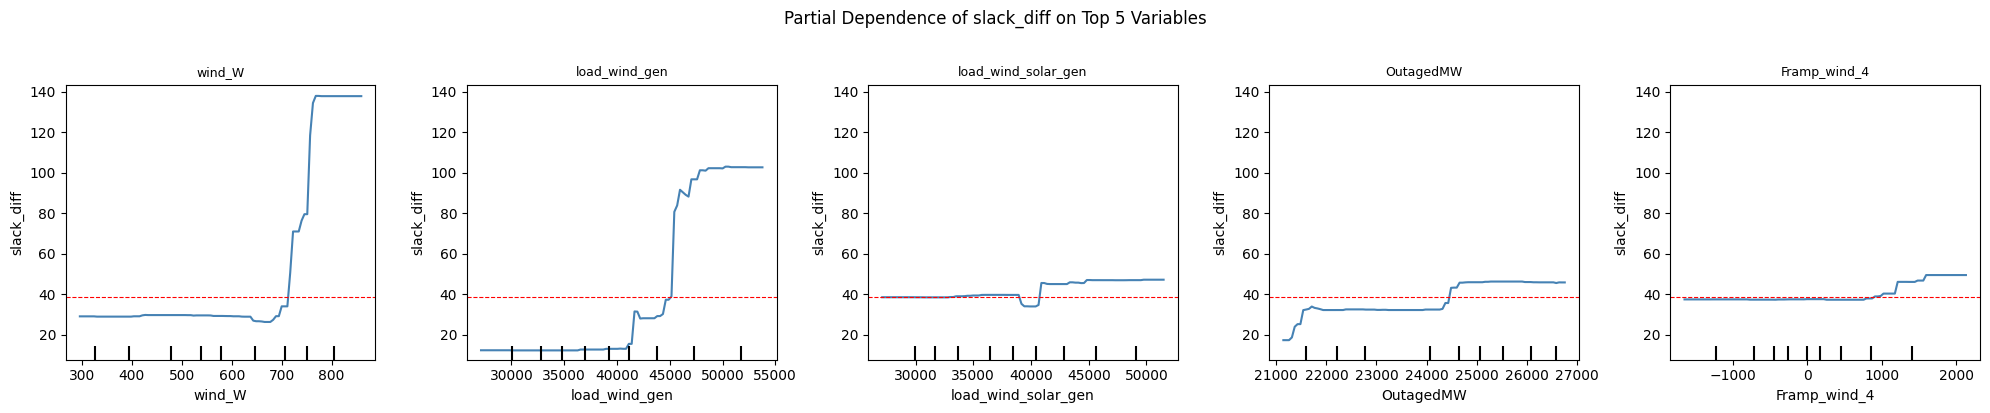

In [125]:
# price of node 636 
x_var = df_phy.columns.drop(['dt','hr']).tolist()
df_price['slack_diff']= df_price['rt_slack'] - df_price['da_slack']
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']
rf_importance(df_price_636, x_var,'slack_diff')
rf_pdp(df_price_636, x_var,'slack_diff')
# lr_importance(df_price_636, x_var,'slack_diff')

── Model Performance ──────────────────
  Train MSE : 640.52
── Model Performance ──────────────────
  Train RMSE : 25.31
  Train R²   : 0.8221
  CV R²      : 0.1564  (5-fold)
  CV RMSE    : 54.16  (5-fold)
───────────────────────────────────────
───────────────────────────────────────

Top variables:
load_wind_gen          0.271824
OutagedMW              0.101547
Framp_lws_total_3      0.050743
load_wind_solar_gen    0.042452
solar_E                0.032390
dtype: float64


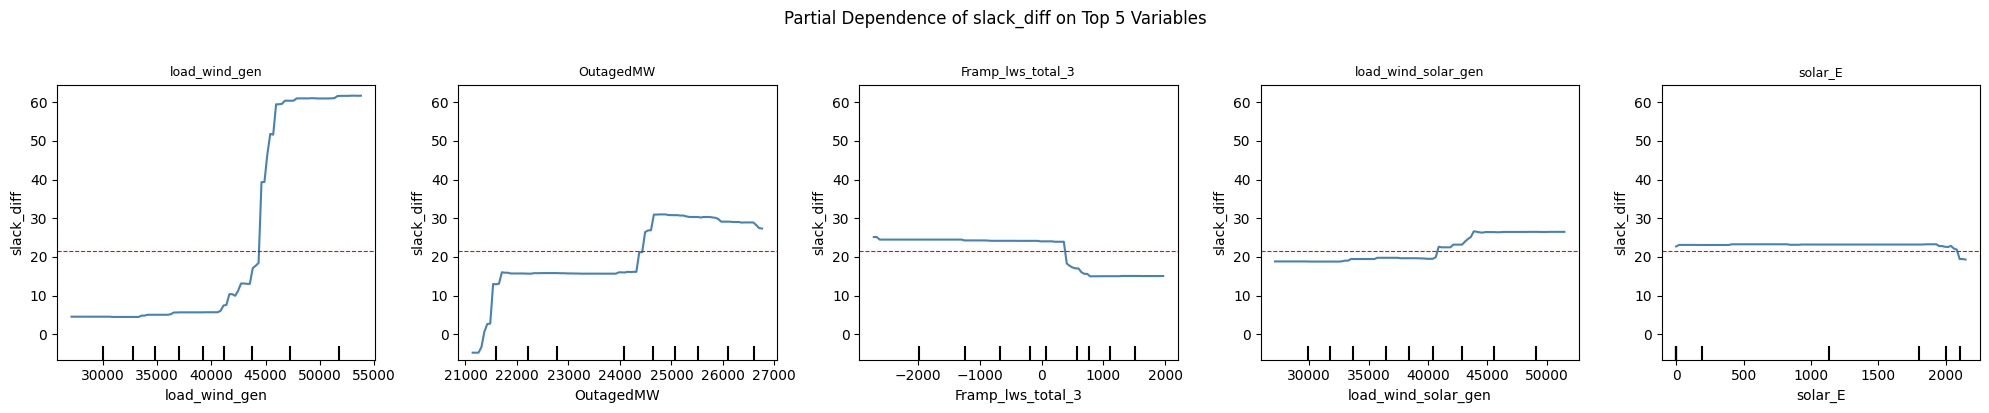

In [126]:
# price of node 636 
x_var = df_phy.columns.drop(['dt','hr']).tolist()
df_price['slack_diff']= df_price['rt_slack'] - df_price['da_slack']
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']
df_price_636.loc[df_price_636['slack_diff']>150,'slack_diff']=150
df_price_636.loc[df_price_636['slack_diff']<=-150,'slack_diff']=-150
rf_importance(df_price_636, x_var,'slack_diff')
rf_pdp(df_price_636, x_var,'slack_diff')
# lr_importance(df_price_636, x_var,'slack_diff')

In [ ]:
# price of node 636 
x_var = df_phy.columns.drop(['dt','hr']).tolist()
df_price['slack_diff']= df_price['rt_slack'] - df_price['da_slack']
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']                                          
df_price_636.loc[df_price_636['slack_diff']>150,'slack_diff']=150
df_price_636.loc[df_price_636['slack_diff']<=-150,'slack_diff']=-150
rf_importance(df_price_636, x_var,'slack_diff')
rf_pdp(df_price_636, x_var,'slack_diff')

<Axes: >

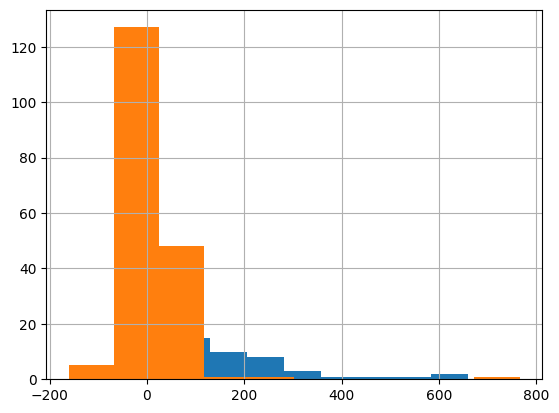

In [117]:
df_price_636 = df_price[df_price['node_num']==636] 
df_price_636 = df_price_636[df_price_636['dt']>='2026-03-17']
df_price_636[df_price_636['load_wind']>20000].slack_diff.hist()
df_price_636[df_price_636['load_wind']<20000].slack_diff.hist()


In [29]:
current_day= df_profit[df_profit['dt']=='2026-03-30']
print(current_day.groupby(['strategy','incdec'])["net_pnl"].sum())
display(current_day.sort_values(by=['net_pnl'],ascending=True).iloc[:10,:10])

strategy  incdec   
Darwin    Decrement         0.000000
          Increment   -551844.707397
Fourier   Decrement     39380.783718
          Increment   -823031.738811
Name: net_pnl, dtype: float64


,dt,hr,BAA,incdec,strategy,dalmp,rtlmp,clear_mw,node_num,net_pnl
48907,2026-03-30,12,E,Increment,Darwin,42.9347,3668.26,4.102,113,-14879.288381
48908,2026-03-30,14,E,Increment,Darwin,54.2829,2363.15,4.102,113,-9479.176844
48909,2026-03-30,13,E,Increment,Darwin,52.8353,2211.44,4.102,113,-8862.800479
48910,2026-03-30,13,E,Increment,Darwin,52.8353,2211.44,4.102,113,-8862.800479
48911,2026-03-30,16,E,Increment,Darwin,90.1199,1695.50,4.102,1092,-6593.473170
48914,2026-03-30,16,E,Increment,Darwin,85.2090,1662.42,4.102,858,-6477.923522
48913,2026-03-30,16,E,Increment,Darwin,85.2090,1662.42,4.102,858,-6477.923522
48912,2026-03-30,16,E,Increment,Darwin,85.2090,1662.42,4.102,858,-6477.923522
48915,2026-03-30,16,E,Increment,Darwin,82.2870,1648.76,4.102,1030,-6433.876246
48917,2026-03-30,16,E,Increment,Darwin,90.4638,1654.83,4.102,425,-6425.234152


In [ ]:
n_buckets = 4  # however many buckets you want
pd.set_option('display.float_format', '{:.2f}'.format)
df_analysis= df_profit.copy()
df_analysis['load_wind_gen_bucket'] = pd.qcut(
    df_analysis['load_wind_gen'],
    q=n_buckets,
    labels=False,       
    duplicates='drop'    
)
print(df_analysis.groupby(['load_wind_gen_bucket','incdec','strategy'])['net_pnl'].sum().reset_index())

df_analysis2= df_price.copy()
df_analysis2['load_wind_gen_bucket'] = pd.qcut(
    df_analysis2['load_wind_gen'],
    q=n_buckets,
    labels=False,        
    duplicates='drop'    
)
df_analysis2['rt_da_lmp']= df_analysis2['rt_value'] - df_analysis2['da_value']
df_analysis2.groupby(['load_wind_gen_bucket'])['rt_da_lmp'].mean().reset_index()


    load_wind_gen_bucket     incdec strategy    net_pnl
0                      0  Decrement   Darwin    3267.52
1                      0  Decrement  Fourier   -2223.07
2                      0  Increment   Darwin  -64800.92
3                      0  Increment  Fourier  182622.15
4                      1  Decrement   Darwin    7402.89
5                      1  Decrement  Fourier   15165.65
6                      1  Increment   Darwin   49638.40
7                      1  Increment  Fourier  126940.90
8                      2  Decrement   Darwin   32279.87
9                      2  Decrement  Fourier   36134.87
10                     2  Increment   Darwin -279828.60
11                     2  Increment  Fourier -459288.05
12                     3  Decrement   Darwin 1030919.18
13                     3  Decrement  Fourier  104369.26
14                     3  Increment   Darwin -809500.62
15                     3  Increment  Fourier -863427.31


,load_wind_gen_bucket,rt_da_lmp
0,0,20.45
1,1,13.59
2,2,57.17
3,3,133.30


In [151]:
n_buckets = 4  # however many buckets you want
pd.set_option('display.float_format', '{:.2f}'.format)
df_analysis= df_profit_ftp.copy()
df_analysis['load_wind_gen_bucket'] = pd.qcut(
    df_analysis['load_wind_gen'],
    q=n_buckets,
    labels=False,       
    duplicates='drop'    
)
print(df_analysis.groupby(['load_wind_gen_bucket','incdec','strategy'])['net_pnl'].sum().reset_index())

df_analysis2= df_price.copy()
df_analysis2['load_wind_gen_bucket'] = pd.qcut(
    df_analysis2['load_wind_gen'],
    q=n_buckets,
    labels=False,        
    duplicates='drop'    
)
df_analysis2['rt_da_lmp']= df_analysis2['rt_value'] - df_analysis2['da_value']
df_analysis2.groupby(['load_wind_gen_bucket'])['rt_da_lmp'].mean().reset_index()


    load_wind_gen_bucket     incdec strategy   net_pnl
0                      0  Decrement   Darwin -12534.43
1                      0  Decrement  Fourier  -4684.80
2                      0  Increment   Darwin  63138.50
3                      0  Increment  Fourier  46892.40
4                      1  Decrement   Darwin   -753.88
5                      1  Decrement  Fourier   3316.21
6                      1  Increment   Darwin  24314.50
7                      1  Increment  Fourier  52085.57
8                      2  Decrement   Darwin   2560.24
9                      2  Decrement  Fourier  -6151.67
10                     2  Increment   Darwin   8386.40
11                     2  Increment  Fourier  55336.34
12                     3  Decrement   Darwin -18129.45
13                     3  Decrement  Fourier  -1466.73
14                     3  Increment   Darwin   2377.14
15                     3  Increment  Fourier  10541.60


,load_wind_gen_bucket,rt_da_lmp
0,0,20.45
1,1,13.59
2,2,57.17
3,3,133.30


In [193]:
# To see if current day falls under which bucket for LWG
# wind data
df_wind = sql_functions.download_df_from_sql_db(
    "select dt,hr, Gen_MW, baa_zone as BAA "
    "from spp_physical.baa_zonal_latest_wind_forecast "
    "where dt = '2026-04-01'")

df_wind = df_wind.pivot_table(index=['dt', 'hr'], columns='BAA', values='Gen_MW').reset_index()
df_wind.columns.name = None
df_wind = df_wind.rename(columns={'E': 'wind_E', 'W': 'wind_W'})
df_wind['wind_total'] = df_wind['wind_E']+df_wind['wind_W']
df_wind['dt'] = df_wind['dt'].astype(str)
df_wind.sort_values(by = ['dt','hr'],inplace=True)
df_wind = df_wind.ffill().bfill()

# load data
df_load = sql_functions.download_df_from_sql_db(
    "select dt,hr, load_MW, baa_zone as BAA "
    "from spp_temp.baa_zonal_latest_load_forecast_mte")
df_load['dt'] = df_load['dt'].astype(str)
df_load = df_load[df_load['dt'].isin(df_wind['dt'].unique())]
df_load = df_load.pivot_table(index=['dt', 'hr'], columns='BAA', values='load_MW').reset_index()
df_load.columns.name = None
df_load = df_load.rename(columns={'E': 'load_E', 'W': 'load_W'})
df_load['load_total'] = df_load['load_E']+df_load['load_W']

# genoutage data 
df_out = sql_functions.download_df_from_sql_db(
    "select dtofDownload,dthr, OutagedMW, baa_zone as BAA "
    "from spp_physical.GenOutagebyFuelTypeRaw ")

df_out['dt'] = df_out['dthr'].dt.strftime('%Y-%m-%d')
df_out['hr'] = df_out['dthr'].dt.hour.astype(int)+1
df_out['dt'] = df_out['dt'].astype(str)
df_out = df_out[df_out['dt'].isin(df_wind['dt'].unique())]
df_out = df_out.drop_duplicates(['dt','hr'],keep="last")
df_out = df_out[df_out['BAA']=='T']
df_out = df_out[['dt','hr','OutagedMW']]

# merge them 
df_temporary=df_wind.merge(df_load, on=['dt','hr']).merge(df_out,on=['dt','hr'])
df_temporary['lwg'] = df_temporary['load_total'] - df_temporary['wind_total'] + df_temporary['OutagedMW']
buckets = pd.read_csv('/var/www/python/Qingcheng/WFiles/bucket.csv')
parsed = buckets.iloc[:, 1].str.strip('(]').str.split(', ', expand=True).astype(float)
bins = [parsed.iloc[0, 0]] + parsed.iloc[:, 1].tolist()
print(bins)
df_temporary['lwg_bucket'] = pd.cut(df_temporary['lwg'], bins=bins, labels=[0, 1, 2, 3])
df_temporary=df_temporary[['dt','hr','lwg','lwg_bucket']]

[np.float64(24225.549), 32664.97, 37070.54, 42879.03, 56944.91]


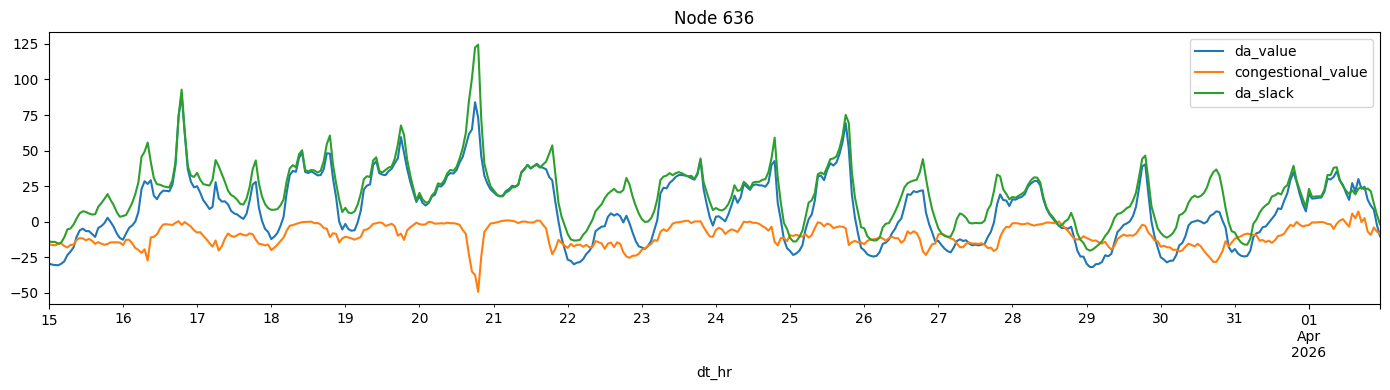

In [ ]:
from nighthawk.data.network import node
import matplotlib.pyplot as plt

new_data = sql_functions.download_df_from_sql_db(
    "select dt,hr, node_num,da_value,congestional_value,da_value-congestional_value-marginalloss_value as da_slack "
    "from spp_temp.settlement_location_da_hourly_mte "
    "where dt = '2026-04-01' and node_num= 636 ")
node = node.Node([636],'SPP')
node_info= node.get_price('2026-03-15', '2026-03-31',  ['LMP','MCC','Slack'], ['DA'],
                  'hourly')
node_info2=node_info.rename(columns={"da_total":'da_value','da_congestion':'congestional_value'})
df_plot=pd.concat([node_info2,new_data])

df_plot['dt_hr'] = pd.to_datetime(df_plot['dt']) + pd.to_timedelta(df_plot['hr']-1, unit='h')
df_plot.set_index('dt_hr')[['da_value', 'congestional_value', 'da_slack']].plot(figsize=(14,4), title='Node 636')
plt.tight_layout()
plt.show()

node = node.Node([636],'SPP')
node_info= node.get_price('2026-03-15', '2026-04-01',  ['LMP','MCC','Slack'], ['DA'],
                  'hourly')
df_plot2=node_info.rename(columns={"da_total":'da_value','da_congestion':'congestional_value'})

df_plot2['dt_hr'] = pd.to_datetime(df_plot2['dt']) + pd.to_timedelta(df_plot2['hr']-1, unit='h')
df_plot2.set_index('dt_hr')[['da_value', 'congestional_value', 'da_slack']].plot(figsize=(14,4), title='Node 636')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
df_plot[df_plot['dt'].astype(str)=='2026-04-01'].reset_index(drop=True)['da_value'].plot(ax=ax, label='mte', color='tomato')
df_plot2[df_plot2['dt'].astype(str)=='2026-04-01'].reset_index(drop=True)['da_value'].plot(ax=ax, label='ftp', color='steelblue')
ax.legend()
ax.grid(True)
plt.show()


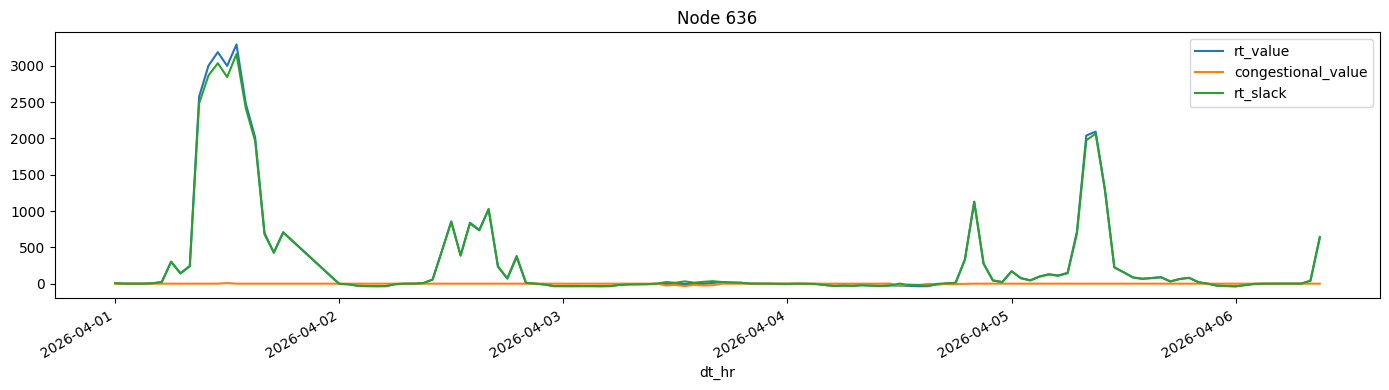

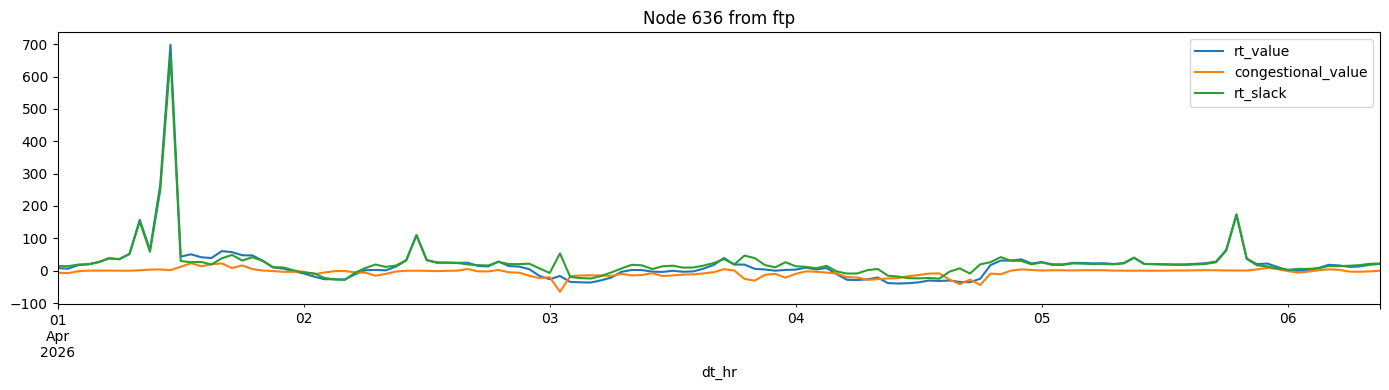

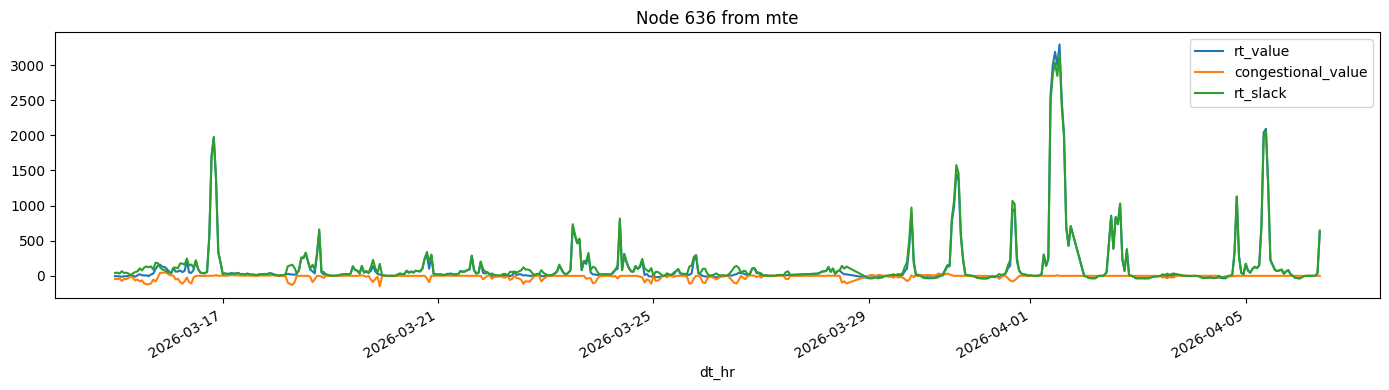

/opt/venvs/prod-py312/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


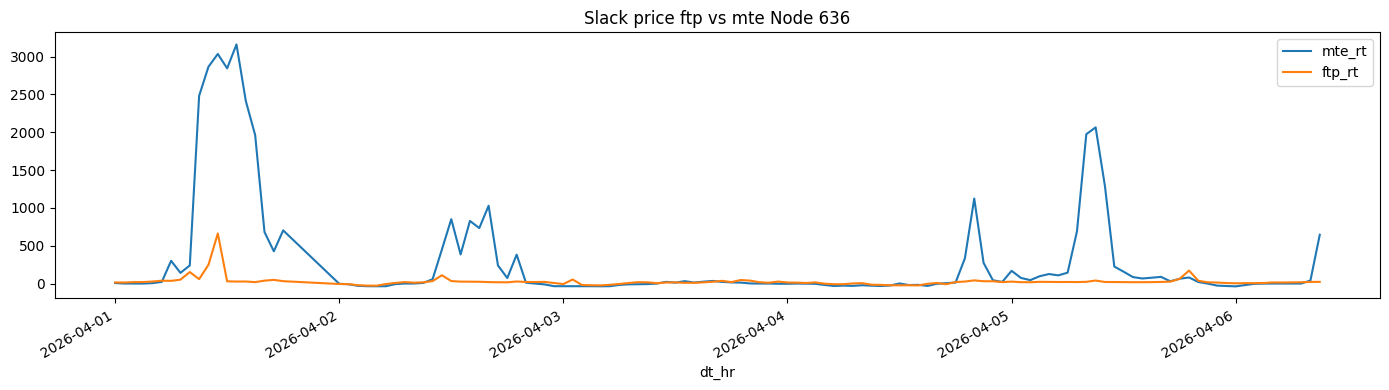

In [7]:
# RT price analysis

from nighthawk.data.network import node
import matplotlib.pyplot as plt
import numpy as np 

# show the mte rt price 
new_data = sql_functions.download_df_from_sql_db(
    "select dt,hr, node_num,rt_value,congestional_value,rt_value-congestional_value-marginalloss_value as rt_slack "
    "from spp_temp.settlement_location_rt_hourly_mte "
    "where dt >= '2026-04-01' and node_num= 636 ")

new_data['dt_hr'] = pd.to_datetime(new_data['dt']) + pd.to_timedelta(new_data['hr']-1, unit='h')
new_data.set_index('dt_hr')[['rt_value', 'congestional_value', 'rt_slack']].plot(figsize=(14,4), title='Node 636')
plt.tight_layout()
plt.show()

# show the latest ftp rt price 
nodal = node.Node([636],'SPP')
node_info= nodal.get_price('2026-04-01', '2026-04-06',  ['LMP','MCC','Slack'], ['RT'],
                  'hourly')
ftp_data=node_info.rename(columns={"rt_total":'rt_value','rt_congestion':'congestional_value'})
ftp_data['dt_hr'] = pd.to_datetime(ftp_data['dt']) + pd.to_timedelta(ftp_data['hr']-1, unit='h')
ftp_data.set_index('dt_hr')[['rt_value', 'congestional_value', 'rt_slack']].plot(figsize=(14,4), title='Node 636 from ftp')
plt.tight_layout()
plt.show()


# show the history rt price
mte_rt = sql_functions.download_df_from_sql_db(
    "select dt,hr, node_num,rt_value,congestional_value,rt_value-congestional_value-marginalloss_value as rt_slack "
    "from spp_temp.settlement_location_rt_hourly_mte "
    "where dt >= '2026-03-15' and node_num= 636 ")
mte_rt = mte_rt.sort_values(['dt', 'hr']).reset_index(drop=True)
mte_rt['dt_hr'] = pd.to_datetime(mte_rt['dt']) + pd.to_timedelta(mte_rt['hr']-1, unit='h')
mte_rt.set_index('dt_hr')[['rt_value', 'congestional_value', 'rt_slack']].plot(figsize=(14,4), title='Node 636 from mte')
plt.tight_layout()
plt.show()

# show the comparison of the rt price between them 
merged_data= mte_rt.merge(ftp_data, on=['dt','hr'])
merged_data = merged_data.sort_values(['dt', 'hr']).reset_index(drop=True)
merged_data['dt_hr'] = pd.to_datetime(merged_data['dt']) + pd.to_timedelta(merged_data['hr']-1, unit='h')
merged_data['sqrt_mte'] = np.sqrt(merged_data['rt_slack_x']).fillna(0)
merged_data=merged_data.rename(columns={'rt_slack_y':"ftp_rt",'rt_slack_x':'mte_rt'})
merged_data = merged_data[merged_data['dt'].astype(str)>='2026-04-01']
merged_data.set_index('dt_hr')[['mte_rt', 'ftp_rt']].plot(figsize=(14,4), title='Slack price ftp vs mte Node 636')
plt.tight_layout()
plt.show()

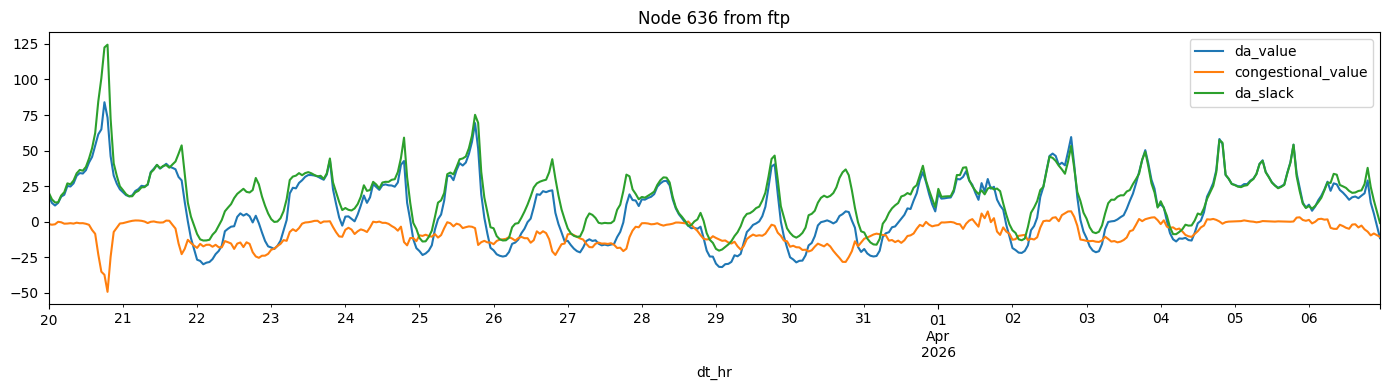

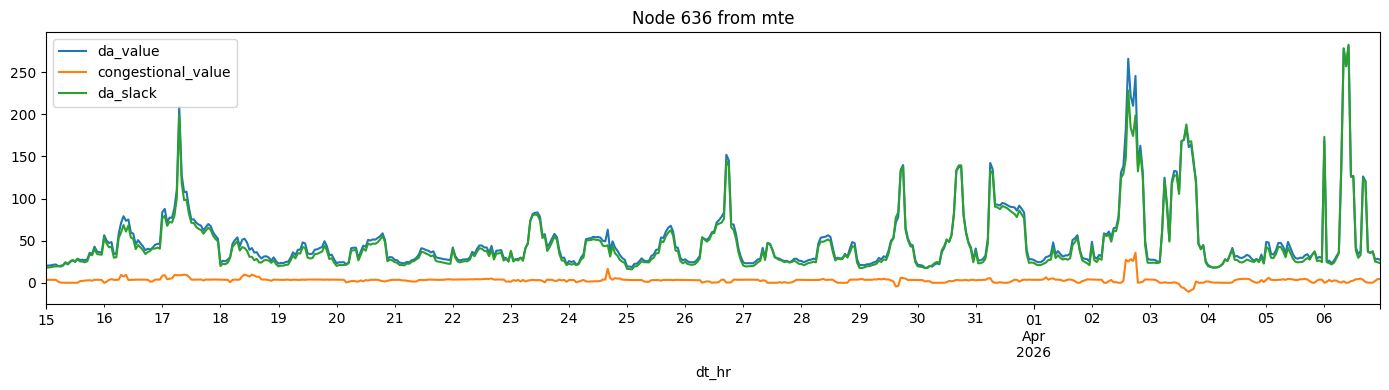

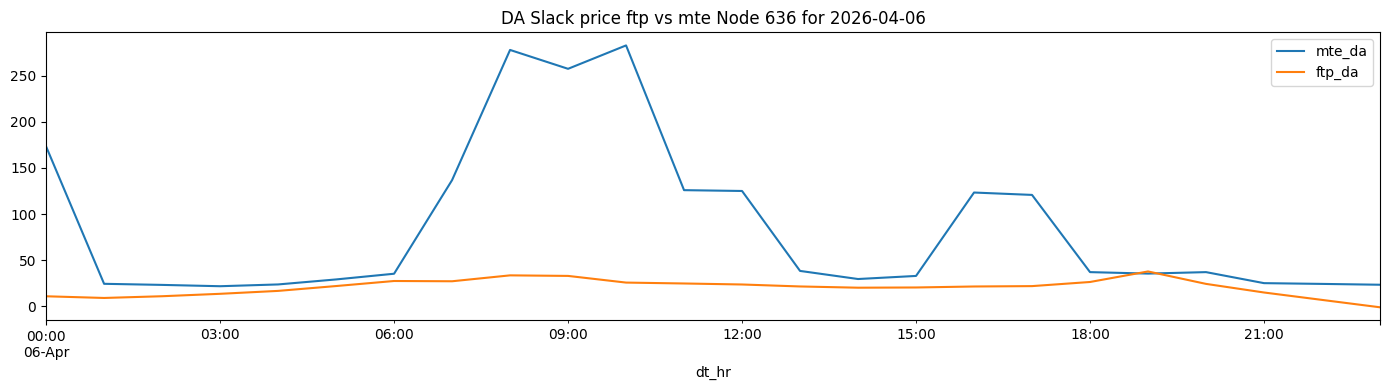

In [6]:
# DA price on the ftp 
today_date='2026-04-06'
nodal = node.Node([636],'SPP')
node_info= nodal.get_price('2026-03-20', today_date,  ['LMP','MCC','Slack'], ['DA'],
                  'hourly')
ftp_data=node_info.rename(columns={"da_total":'da_value','da_congestion':'congestional_value'})

ftp_data['dt_hr'] = pd.to_datetime(ftp_data['dt']) + pd.to_timedelta(ftp_data['hr']-1, unit='h')
ftp_data.set_index('dt_hr')[['da_value', 'congestional_value', 'da_slack']].plot(figsize=(14,4), title='Node 636 from ftp')
plt.tight_layout()
plt.show()

mte_da = sql_functions.download_df_from_sql_db(
    "select dt,hr, node_num,da_value,congestional_value,da_value-congestional_value-marginalloss_value as da_slack "
    "from spp_temp.settlement_location_da_hourly_mte "
    "where dt >= '2026-03-15' and node_num= 636 ")
mte_da = mte_da.sort_values(['dt', 'hr']).reset_index(drop=True)
mte_da['dt_hr'] = pd.to_datetime(mte_da['dt']) + pd.to_timedelta(mte_da['hr']-1, unit='h')
mte_da.set_index('dt_hr')[['da_value', 'congestional_value', 'da_slack']].plot(figsize=(14,4), title='Node 636 from mte')
plt.tight_layout()
plt.show()


merged_data= mte_da.merge(ftp_data, on=['dt','hr'])
merged_data = merged_data.sort_values(['dt', 'hr']).reset_index(drop=True)
merged_data['dt_hr'] = pd.to_datetime(merged_data['dt']) + pd.to_timedelta(merged_data['hr']-1, unit='h')
merged_data['sqrt_mte'] = np.sqrt(merged_data['da_slack_x']).fillna(0)
merged_data=merged_data.rename(columns={'da_slack_y':"ftp_da",'da_slack_x':'mte_da'})
merged_data = merged_data[merged_data['dt'].astype(str)>=today_date]
merged_data.set_index('dt_hr')[['mte_da', 'ftp_da']].plot(figsize=(14,4), title=f'DA Slack price ftp vs mte Node 636 for {today_date}')
plt.tight_layout()
plt.show()